# Incomplete Cholesky factorization as a preconditioner
Elisa Klunder (s5190940) and Dries Wedda (s4745329), 12.12.2025

The matrix resulting from the discretization of the Poisson equation in two dimensions (discussed in the introduction lecture) is an example of a Stieltjes matrix. Implement the algorithm you previously discussed for no fill-in incomplete Cholesky and apply it to this matrix. For different values of $m$ (see notation in lecture notes), investigate the condition number of the preconditioned matrix and the number of iterations necessary for PCG to converge.

- Implement the algorithm you previously discussed for no fill-in incomplete Cholesky
- Implement PCG
- Setup experiment
- Vary $m$ and investigate $\kappa$ and steps until convergence


In [ ]:
import numpy as np
from scipy.sparse import diags


# source: https://stackoverflow.com/questions/5842903/block-tridiagonal-matrix-python for scipy.sparse.diags
# source: https://thauwa.me/2021/12/03/how-to-create-a-block-tridiagonal-matrix-using-numpy-in-python-ft-personal-trauma-variables/
# for numpy.kron
def make_stieltjes(m: int) -> np.ndarray:
    """Create Stieltjes matrix resulting from discretization of the Poisson equation in two dimensions.

    This is an `m^2` by `m^2` block tridiagonal matrix. It has `D` on main diagonal, and `-I` off-diagonal.
    `D` is again an `m` by `m` tridiagonal matrix, with 4 on main diagonal, and -1 off-diagonal.
    """
    D = diags(diagonals=[4, -1, -1], offsets=[0, 1, -1], shape=(m, m), dtype=int).toarray()       # create D blocks
    I = np.eye(m, dtype=int)                                                                      # for -I blocks

    I_above = np.eye(m, k=1, dtype=int)     # identity shifted one above
    I_below = np.eye(m, k=-1, dtype=int)    # identity shifted one below

    return (
        np.kron(I_above, -I)                # -I above diagonal
        + np.kron(I, D)                     # D on diagonal
        + np.kron(I_below, -I)              # -I below diagonal
    )

In [ ]:
def compute_Z(A: np.ndarray) -> np.ndarray:
    """Assumes A is symmetric which is a reasonable assumption, since it should be PSD."""
    return (A != 0).astype(int)


def ichol_helper(A: np.ndarray, Z: np.ndarray, n: int) -> np.ndarray:
    """Recursive helper function that implements the algorithm."""
    if n == 1:
        return np.sqrt(A)

    alpha = A[0,0]
    v = A[1:n, 0]
    B = A[1:n, 1:n]
    w = v / np.sqrt(alpha) * Z[1:n, 0]
    A_1 = (B - np.outer(w, w.T)) * Z[1:n, 1:n]
    H_1 = ichol_helper(A_1, Z[1:n, 1:n], n - 1)

    return np.block([
        [np.sqrt(alpha), np.zeros(shape=(n - 1, ))],
        [np.atleast_2d(w).T, H_1]],
        )


def ichol(A: np.ndarray) -> np.ndarray:
    """Wrap implementation so the user has to supply fewer arguments."""
    Z = compute_Z(A)
    return ichol_helper(A, Z, n=A.shape[0])

In [ ]:
import scipy


# https://stackoverflow.com/questions/64056586/how-can-i-count-number-of-iterations-that-ran-for-sparse-linear-solver-in-scipy
def run_experiment_pre(A: np.ndarray, b: np.ndarray) -> tuple[int, float]:
    def nonlocal_iterate(_):
        nonlocal iters
        iters += 1

    iters = 0
    R = ichol(A)
    M = scipy.linalg.inv(R) @ scipy.linalg.inv(R.T)
    scipy.sparse.linalg.cg(A, b, M = M, callback=nonlocal_iterate)  # ignoring result
    c = np.linalg.cond(M)
    return iters, c


def run_experiment_basic(A: np.ndarray, b: np.ndarray) -> tuple[int, float]:
    def nonlocal_iterate(_):
        nonlocal iters
        iters += 1

    iters = 0
    A = make_stieltjes(m)
    scipy.sparse.linalg.cg(A, b, callback=nonlocal_iterate)  # ignoring result
    c = np.linalg.cond(A)
    return iters, c


all_iters_pre = []
all_c_pre = []
all_iters_basic = []
all_c_basic = []

max_m = 40
m_values = range(1, max_m + 1)

for m in range(1, max_m + 1):
    A = make_stieltjes(m)
    b = np.random.random((m * m, ))

    iters, c = run_experiment_pre(A, b)
    all_iters_pre.append(iters)
    all_c_pre.append(c)
    iters, c = run_experiment_basic(A, b)
    all_iters_basic.append(iters)
    all_c_basic.append(c)

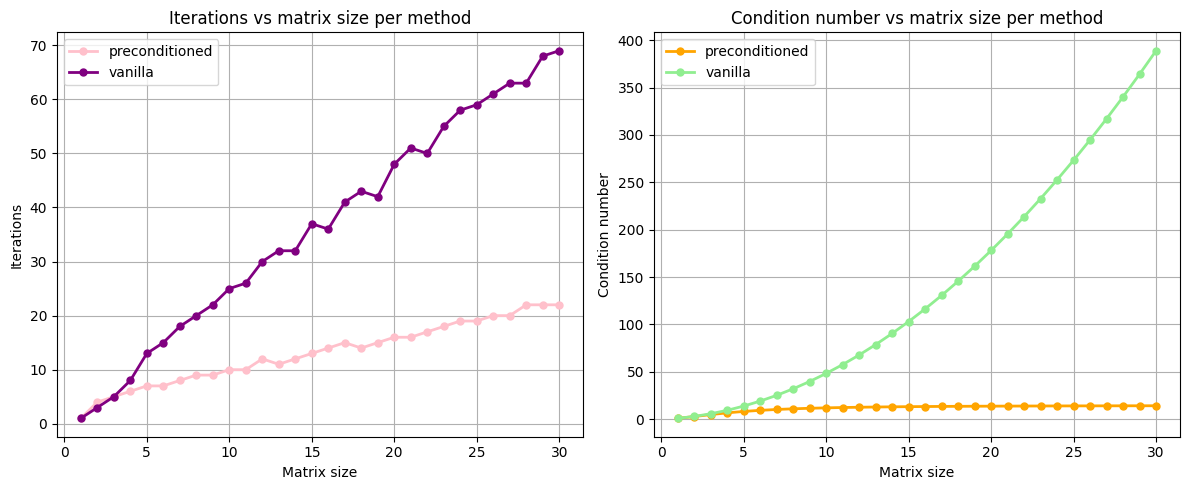

In [213]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(m_values, all_iters_pre, marker="o", linewidth=2, markersize=5, color="pink", label="preconditioned")
ax1.plot(m_values, all_iters_basic, marker="o", linewidth=2, markersize=5, color="purple", label="vanilla")
ax1.set_xlabel("Matrix size")
ax1.set_ylabel("Iterations")
ax1.set_title("Iterations vs matrix size per method")
ax1.legend()
ax1.grid()

ax2.plot(m_values, all_c_pre, marker="o", linewidth=2, markersize=5, color="orange", label="preconditioned")
ax2.plot(m_values, all_c_basic, marker="o", linewidth=2, markersize=5, color="lightgreen", label="vanilla")
ax2.set_xlabel("Matrix size")
ax2.set_ylabel("Condition number")
ax2.set_title("Condition number vs matrix size per method")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()